In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import os
import matplotlib.pyplot as plt
import openml
import yaml
import tqdm
from pymoo.indicators.hv import HV
import warnings

from utility import compute_min_max, get_pareto_front, compute_ranks, compute_extremes, get_all_dataframes, get_group_task_ids

In [2]:
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)

FONT_SIZE = 12

keys = ["random", "so-smac", "mo-smac", "so-asha", "mo-asha", "nsga2"]

cmap = plt.get_cmap("Set1")   # ColorBrewer Set1 (9 colors)

COLORS = {key: cmap(i) for i, key in enumerate(keys)}

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.weight": "normal",
    "font.size": FONT_SIZE,
    "axes.labelsize": FONT_SIZE,      # axis labels
    "axes.titlesize": FONT_SIZE,      # subplot titles
    "xtick.labelsize": FONT_SIZE,     # x tick labels
    "ytick.labelsize": FONT_SIZE,     # y tick labels
    "legend.fontsize": FONT_SIZE,     # legend
    "figure.titlesize": FONT_SIZE + 4     # suptitle
})

In [3]:
data = pd.read_csv("./data/base_model_pools.csv", index_col=0)
data.index.name = "index"
data_meta = pd.read_csv("./data/base_model_pools_meta.csv")

In [4]:

assert np.all(np.abs(data["ensemble_size"].to_numpy() - 1.0) < 1e-12), np.all(np.abs(data["avg_gap"].to_numpy()) < 1e-12)

In [5]:
if not os.path.exists("./data/processed_data"):
    os.makedirs("./data/processed_data")

if os.path.exists("./data/processed_data/min_max.yaml"):
    with open("./data/processed_data/min_max.yaml", "r") as f:
        min_max_values = yaml.safe_load(f)
else:
    all_df = get_all_dataframes()
    min_max_values = compute_min_max(all_df)
    with open("./data/processed_data/min_max.yaml", "w") as f:
        yaml.dump(min_max_values, f)
    del all_df
assert len(min_max_values) == 104

In [6]:
if os.path.exists("./data/processed_data/extremes.yaml"):
    with open("./data/processed_data/extremes.yaml", "r") as f:
        extremes = yaml.safe_load(f)
else:
    all_df = get_all_dataframes()
    extremes = compute_extremes(min_max_values, all_df)
    with open("./data/processed_data/extremes.yaml", "w") as f:
        yaml.dump(extremes, f)
    del all_df
assert len(extremes) == 104

In [7]:
def min_distance(vectors, paret_front, ignore_self=False):
    diff = vectors[:, None, :] - paret_front[None, :, :]
    dist = np.linalg.norm(diff, axis=2)
    if ignore_self:
        np.fill_diagonal(dist, np.inf)
    return np.min(dist, axis=1)

def compute_spread(extent, sum_deviations, denom):
    assert np.isfinite(extent) and np.isfinite(sum_deviations) and np.isfinite(denom), "Values must be finite"
    return (extent + sum_deviations) / (extent + denom)

def compute_extent(pareto_front, cols, extremes):
    extremes_array = np.array([[e[col] for col in cols] for e in extremes.values()])
    sum_extremes = np.sum(min_distance(extremes_array, pareto_front))
    return sum_extremes

def compute_uniformity_components(pareto_front, cols):
    assert len(pareto_front) > 0, "Pareto front is empty"
    if len(pareto_front) == 1:
        return 1.0, 1.0 

    distances = min_distance(pareto_front, pareto_front, ignore_self=True)
    assert not np.any(np.isinf(distances)), "Distances contain infinity"
        
    d_mean = np.mean(distances)
    assert np.abs(d_mean) >= 1e-14, "Mean distance is too small"

    sum_deviations = np.sum(np.abs(distances - d_mean))
    return sum_deviations, len(pareto_front) * d_mean

def compute_uniformity(sum_deviations, denom):
    return sum_deviations / denom


def compute_hvs(data, log_mask, min_arr, max_arr):
    ind = HV(ref_point=[1] * 3)
    data_norm = (data - min_arr) / (max_arr - min_arr)
    hv = ind(data_norm)
    
    data_log_scaled = data.copy()
    data_log_scaled[:, log_mask] = np.log10(data_log_scaled[:, log_mask] + 1e-10)
    min_arr_log = min_arr.copy()
    min_arr_log[log_mask] = np.log10(min_arr_log[log_mask] + 1e-10)
    max_arr_log = max_arr.copy()
    max_arr_log[log_mask] = np.log10(max_arr_log[log_mask] + 1e-10)
    data_log_norm = (data_log_scaled - min_arr_log) / (max_arr_log - min_arr_log)
    hv_log = ind(data_log_norm)
    return hv, hv_log, data_norm

def filter_duplicates(arr):
    unique = []
    for row in arr:
        if not any(np.abs(row - u).sum() < 1e-6 for u in unique):
            unique.append(row)
    return np.array(unique)

In [8]:
METRICS = ["HV", "HV LOG", "N_MODELS", "N_PARETO", "SPREAD", "UNIFORMITY", "EXTENT", "MIN_METRIC", "MIN_INF_TIME", "MIN_ENERGY"]

def compute_metrics(data, min, max, extremes):
    if data.empty:
        return [0, 0, 0, 0, np.inf, np.inf, np.inf,np.inf,np.inf, np.inf]

    cols = ["RMSE", "Log Loss", "1 - ROC AUC", "inference_time", "energy_consumption"]
    cols = [col for col in cols if (~data[col].isna()).sum() > 0]
    
    cols_ens = [f"{c}_ens" for c in cols]
    
    log_mask = [1,2]

    assert "inference_time" in cols and "energy_consumption" in cols and len(cols) == 3
    
    min_arr, max_arr = np.array([min[col] for col in cols]), np.array([max[col] for col in cols])
    hv, hv_log, data_norm = compute_hvs(data[cols].values, log_mask, min_arr, max_arr)
    
    pareto_mask_ens = get_pareto_front(data[cols_ens].values)
    data_norm = data_norm[pareto_mask_ens]

    pareto_front_mask = get_pareto_front(data_norm)
    pareto_front = data_norm[pareto_front_mask]
    pareto_front = filter_duplicates(pareto_front)
    n_pareto = len(pareto_front)
    n_total = data.shape[0]
    
    uniformity_bmp_sum_dev, uniformity_bmp_denom = compute_uniformity_components(pareto_front, cols)
    uniformity_bmp = compute_uniformity(uniformity_bmp_sum_dev, uniformity_bmp_denom)
    extent_bmp = compute_extent(pareto_front, cols, extremes)
    spread_bmp = compute_spread(extent_bmp, uniformity_bmp_sum_dev, uniformity_bmp_denom)
    

    metrics_min = []
    for i in range(len(cols)):
        min_val = data_norm[:, i].min()
        metrics_min.append((min_val - min[cols[i]]) / (max[cols[i]] - min[cols[i]]))

    return [hv, hv_log, n_total, n_pareto, spread_bmp, uniformity_bmp, extent_bmp, *metrics_min]

In [9]:
task_ids = list(data["task_id"].unique())
assert len(task_ids) == 104
seeds = list(data["seed"].unique())
assert len(seeds) == 5
bmg_methods = list(data["bmg_method"].unique())
assert len(bmg_methods) == 6
time_values = sorted([t for t in data["time"].unique() if t >= 0]) + [28800.0]
assert len(time_values) == 32
frequencies = list(data["frequency"].unique())
assert len(frequencies) == 2

task_id_to_idx = {v: i for i, v in enumerate(task_ids)}
seed_to_idx = {v: i for i, v in enumerate(seeds)}
bmg_to_idx = {v: i for i, v in enumerate(bmg_methods)}
time_to_idx = {v: i for i, v in enumerate(time_values)}
freq_to_idx = {v: i for i, v in enumerate(frequencies)}

In [10]:
def process_pool(pool_index, pool_data):
    if pool_data.empty:
        return None

    # Extract metadata efficiently
    row = pool_data.iloc[0]
    task_id = row["task_id"]
    seed = row["seed"]
    bmg_method = row["bmg_method"]
    time = row["time"]
    frequency = row["frequency"]

    # Compute hypervolume
    min_vals, max_vals = min_max_values[task_id]
    ext = extremes[task_id]
    metrics = compute_metrics(pool_data, min_vals, max_vals, ext)
    metrics = [np.nan if not np.isfinite(m) else m for m in metrics]

    return (task_id, seed, bmg_method, time, frequency, metrics)

In [11]:
from concurrent.futures import ProcessPoolExecutor, as_completed


# from joblib import Parallel, delayed

# results = Parallel(n_jobs=-1)(
#     delayed(process_pool)(pool_index, pool_data)
#     for pool_index, pool_data in tqdm.tqdm(grouped)
# )

grouped = data.groupby("pool_index", sort=False)

def process_wrapper(args):
    pool_index, pool_data = args
    return process_pool(pool_index, pool_data)

jobs = list(grouped)  # ensures len(jobs) is known

results = []

with ProcessPoolExecutor(max_workers=12) as executor:
    for res in tqdm.tqdm(
        executor.map(process_wrapper, jobs),
        total=len(jobs)
    ):
        results.append(res)

100%|██████████| 93160/93160 [00:28<00:00, 3321.28it/s]


In [12]:
metrics_over_time = np.zeros((len(task_ids), len(seeds), len(bmg_methods), len(time_values), len(METRICS))) + np.nan
final_metrics = np.zeros((len(task_ids), len(seeds), len(bmg_methods), len(METRICS))) + np.nan
final_metrics_boost = np.zeros((len(task_ids), len(seeds), len(bmg_methods), len(METRICS))) + np.nan

for res in results:
    if res is None:
        continue

    task_id, seed, bmg_method, time, frequency, metrics = res

    i_task = task_id_to_idx[task_id]
    i_seed = seed_to_idx[seed]
    i_bmg = bmg_to_idx[bmg_method]

    if time < 0:
        if frequency == "boost":
            final_metrics_boost[i_task, i_seed, i_bmg] = metrics
            continue
        final_metrics[i_task, i_seed, i_bmg] = metrics
        i_time = len(time_values) - 1
        metrics_over_time[i_task, i_seed, i_bmg, i_time] = metrics
    else:
        if frequency == "boost":
            continue

        i_time = time_to_idx[time]
        metrics_over_time[i_task, i_seed, i_bmg, i_time] = metrics

for metric in METRICS:
    print(f"Metric: {metric}")
    print(np.isnan(metrics_over_time[..., METRICS.index(metric)]).sum() / np.prod(metrics_over_time[..., METRICS.index(metric)].shape), "missing values in metrics over time")
    print(np.isnan(final_metrics[..., METRICS.index(metric)]).sum() / np.prod(final_metrics[..., METRICS.index(metric)].shape), "missing values in final metrics")
    print(np.isnan(final_metrics_boost[..., METRICS.index(metric)]).sum() / np.prod(final_metrics_boost[..., METRICS.index(metric)].shape), "missing values in final metrics boost")

max_spread = np.nanmax(np.take(metrics_over_time, METRICS.index("SPREAD"), axis=-1), axis=(1,2,3))
spread_idx = METRICS.index("SPREAD")
for i_task in range(len(task_ids)):
    for metric in ["SPREAD", "EXTENT", "UNIFORMITY"]:
        max_metric = np.nanmax(np.take(metrics_over_time, METRICS.index(metric), axis=-1), axis=(1,2,3))
        max_metric = max_metric[i_task]
        mask = np.isnan(metrics_over_time[i_task, :, :, :, METRICS.index(metric)])
        mask_final = np.isnan(final_metrics[i_task, :, :, METRICS.index(metric)])
        if np.any(mask):
            metrics_over_time[i_task, :, :, :, METRICS.index(metric)][mask] = max_metric
        if np.any(mask_final):
            final_metrics[i_task, :, :, METRICS.index(metric)][mask_final] = max_metric        

    mask_hv = np.isnan(metrics_over_time[i_task, :, :, :, METRICS.index("HV")])
    mask_hv_final = np.isnan(final_metrics[i_task, :, :, METRICS.index("HV")])
    if np.any(mask_hv):
        metrics_over_time[i_task, :, :, :, METRICS.index("HV")][mask_hv] = 0.0
    if np.any(mask_hv_final):
        final_metrics[i_task, :, :, METRICS.index("HV")][mask_hv_final] = 0.0
        
    mask_hv_log = np.isnan(metrics_over_time[i_task, :, :, :, METRICS.index("HV LOG")])
    mask_hv_log_final = np.isnan(final_metrics[i_task, :, :, METRICS.index("HV LOG")])
    if np.any(mask_hv_log):
        metrics_over_time[i_task, :, :, :, METRICS.index("HV LOG")][mask_hv_log] = 0.0
    if np.any(mask_hv_log_final):
        final_metrics[i_task, :, :, METRICS.index("HV LOG")][mask_hv_log_final] = 0.0

    mask_n_models = np.isnan(metrics_over_time[i_task, :, :, :, METRICS.index("N_MODELS")])
    mask_n_models_final = np.isnan(final_metrics[i_task, :, :, METRICS.index("N_MODELS")])
    if np.any(mask_n_models):
        metrics_over_time[i_task, :, :, :, METRICS.index("N_MODELS")][mask_n_models] = 0.0
    if np.any(mask_n_models_final):
        final_metrics[i_task, :, :, METRICS.index("N_MODELS")][mask_n_models_final] = 0.0

    mask_n_pareto = np.isnan(metrics_over_time[i_task, :, :, :, METRICS.index("N_PARETO")])
    mask_n_pareto_final = np.isnan(final_metrics[i_task, :, :, METRICS.index("N_PARETO")])
    if np.any(mask_n_pareto):
        metrics_over_time[i_task, :, :, :, METRICS.index("N_PARETO")][mask_n_pareto] = 0.0
    if np.any(mask_n_pareto_final):
        final_metrics[i_task, :, :, METRICS.index("N_PARETO")][mask_n_pareto_final] = 0.0


Metric: HV
0.09809695512820513 missing values in metrics over time
0.0019230769230769232 missing values in final metrics
0.0019230769230769232 missing values in final metrics boost
Metric: HV LOG
0.09809695512820513 missing values in metrics over time
0.0019230769230769232 missing values in final metrics
0.0019230769230769232 missing values in final metrics boost
Metric: N_MODELS
0.09809695512820513 missing values in metrics over time
0.0019230769230769232 missing values in final metrics
0.0019230769230769232 missing values in final metrics boost
Metric: N_PARETO
0.09809695512820513 missing values in metrics over time
0.0019230769230769232 missing values in final metrics
0.0019230769230769232 missing values in final metrics boost
Metric: SPREAD
0.09809695512820513 missing values in metrics over time
0.0019230769230769232 missing values in final metrics
0.0019230769230769232 missing values in final metrics boost
Metric: UNIFORMITY
0.09809695512820513 missing values in metrics over time


In [34]:
BMG_DICT = {
    "random": "Random Search",
    "so-smac": "SO-SMAC",
    "mo-smac": "MO-SMAC",
    "so-asha": "SO-ASHA",
    "mo-asha": "MO-ASHA",
    "nsga2": "NSGA-II"
}

from colors import COLORS
COLORS_LIST = list(COLORS.values())
BMG_DICT_COLORS = {
    "random": COLORS_LIST[0],
    "so-smac": COLORS_LIST[1],
    "mo-smac": COLORS_LIST[2],
    "so-asha": COLORS_LIST[3],
    "mo-asha": COLORS_LIST[4],
    "nsga2": COLORS_LIST[5]
}


def plot_bmp_hist(task_ids, metrics_over_time, title=None, metric_name="HV", ranks=True, log_scale=False, legend_loc=None, mode="max"):
    fig, ax = plt.subplots(1,1, figsize=(8, 6))
    ax = np.array(ax).flatten()
    print(f"Plotting {metric_name} using {'ranks' if ranks else 'means'}")

    metric_index = METRICS.index(metric_name)

    task_id_idx = [task_id_to_idx[t] for t in task_ids]
    metric_hist = np.take(metrics_over_time[task_id_idx], metric_index, axis=-1)
    metric_mean = metric_hist.mean(axis=1)
    if ranks:
        metric_ranks = compute_ranks(metric_mean, mode=mode, axis=1)
        metric_ranks_mean = metric_ranks.mean(axis=0)
        metric_ranks_std = metric_ranks.std(axis=0)
        clip_range = (1, len(bmg_methods))
    else:
        metric_mean_mean = metric_mean.mean(axis=0)
        metric_mean_std = metric_mean.std(axis=0)
        clip_range = (0, None)

    for bmg_method in bmg_methods:
        i_bmg = bmg_to_idx[bmg_method]
        times_h = np.array(time_values) / 3600
        if ranks:
            ax[0].fill_between(
                times_h, 
                np.clip(metric_ranks_mean[i_bmg] - metric_ranks_std[i_bmg], *clip_range),
                np.clip(metric_ranks_mean[i_bmg] + metric_ranks_std[i_bmg], *clip_range),
                alpha=0.1,
                color = BMG_DICT_COLORS[bmg_method]
            )
            #ax[0].plot(times_h, metric_ranks_mean[i_bmg], label=BMG_DICT[bmg_method], color=BMG_DICT_COLORS[bmg_method])
        else:
            ax[0].fill_between(
                times_h,
                np.clip(metric_mean_mean[i_bmg] - metric_mean_std[i_bmg], *clip_range),
                np.clip(metric_mean_mean[i_bmg] + metric_mean_std[i_bmg], *clip_range),
                alpha=0.1,
                color=BMG_DICT_COLORS[bmg_method]
            )
            #ax[0].plot(times_h, metric_mean_mean[i_bmg], label=BMG_DICT[bmg_method], color=BMG_DICT_COLORS[bmg_method])
    for bmg_method in bmg_methods:
        i_bmg = bmg_to_idx[bmg_method]
        times_h = np.array(time_values) / 3600
        if ranks:
            ax[0].plot(times_h, metric_ranks_mean[i_bmg], label=BMG_DICT[bmg_method], color=BMG_DICT_COLORS[bmg_method])
        else:
            ax[0].plot(times_h, metric_mean_mean[i_bmg], label=BMG_DICT[bmg_method], color=BMG_DICT_COLORS[bmg_method])

    ax[0].legend(loc=None if legend_loc is None else legend_loc)
    ax[0].set_xlabel("Time [h]")
    ax[0].set_ylabel(f"Mean {metric_name} {'Rank' if ranks else ''}")
    if title is not None:
        ax[0].set_title(title)
    if ranks:
        ax[0].invert_yaxis()
    if log_scale:
        ax[0].set_yscale("log")
    
    plt.savefig(f"./figures/bmg/bmp_{metric_name}_{'ranks' if ranks else 'means'}.pdf")

In [35]:
METRICS = ["Hypervolume NON-LOG", "Hypervolume", "Number of Evaluations", "ONVG", "Spread", "Uniformity", "Extent Gap", "Predictive Performance", "Inference Time", "Energy Consumption"]

Plotting Hypervolume using ranks
Plotting Hypervolume using means


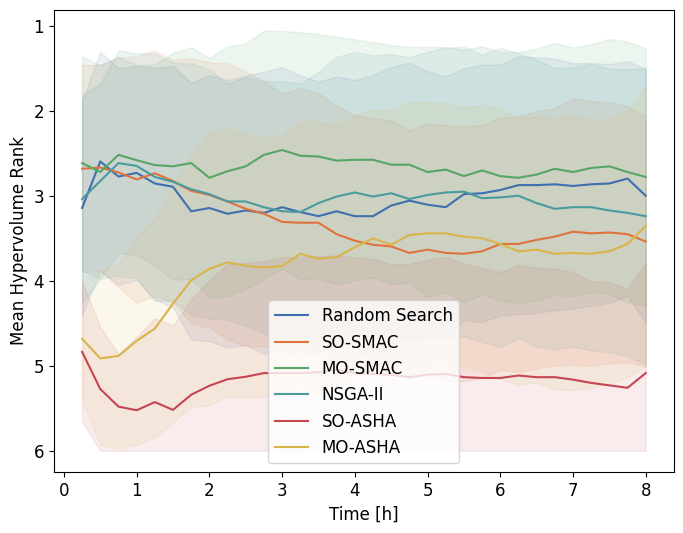

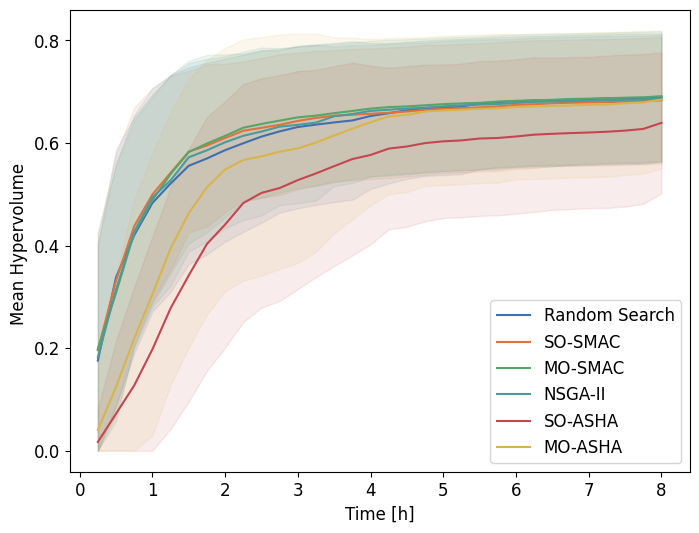

In [36]:
plot_bmp_hist(task_ids, metrics_over_time, metric_name="Hypervolume")
plot_bmp_hist(task_ids, metrics_over_time, metric_name="Hypervolume", ranks=False, log_scale=False)

Plotting Spread using ranks
Plotting Spread using means
Plotting Number of Evaluations using ranks
Plotting Number of Evaluations using means
Plotting ONVG using ranks
Plotting ONVG using means


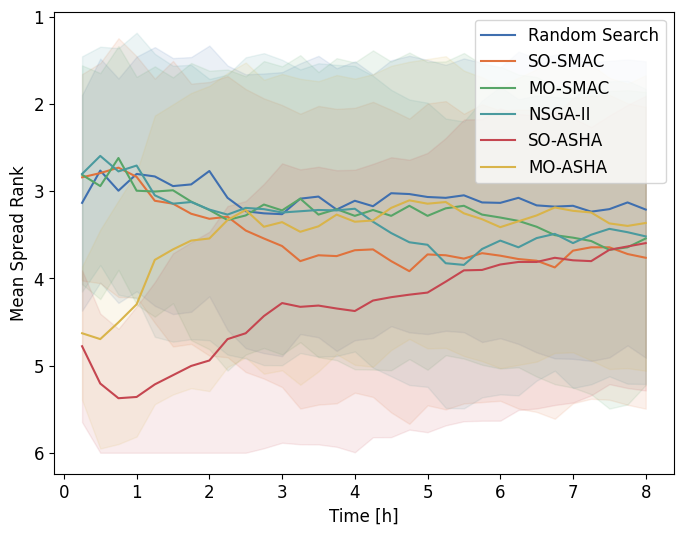

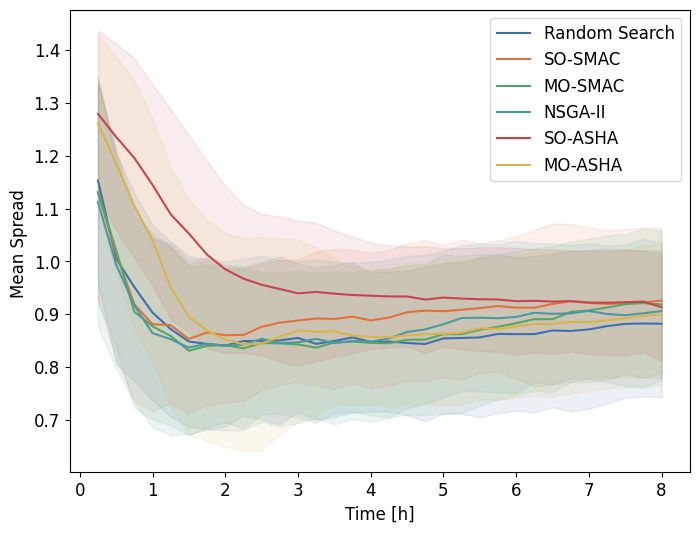

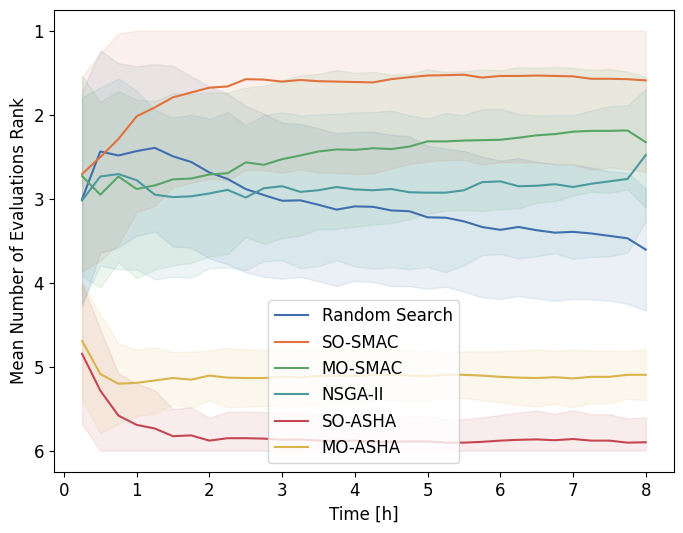

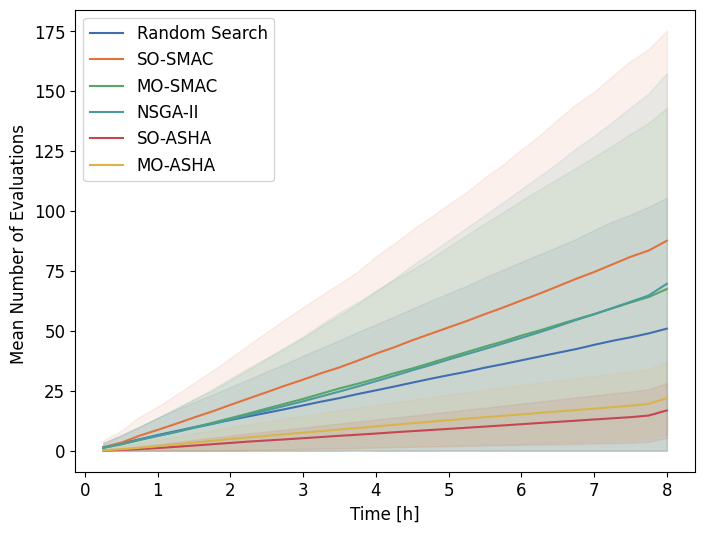

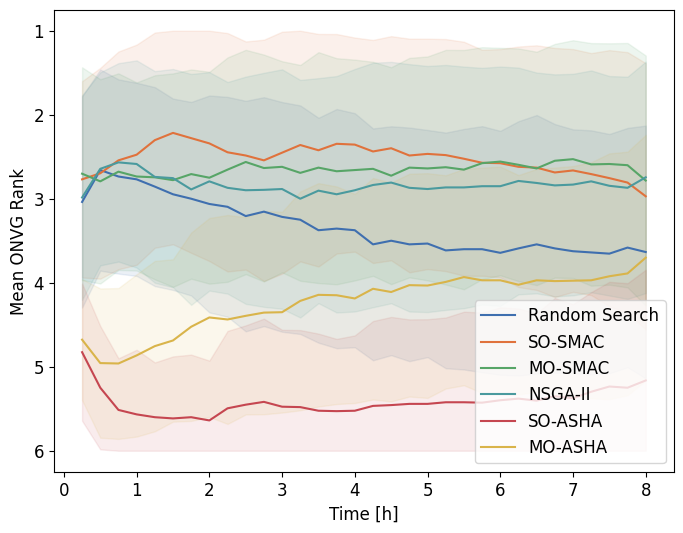

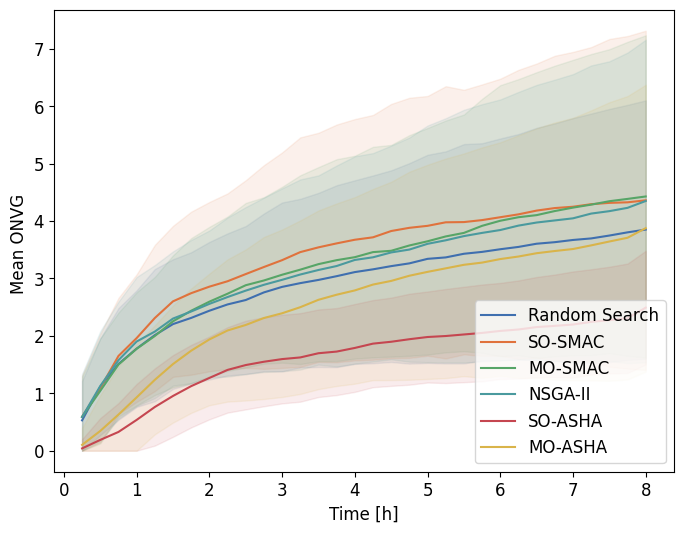

In [ ]:
plot_bmp_hist(task_ids, metrics_over_time, metric_name="Spread", mode="min")
plot_bmp_hist(task_ids, metrics_over_time, metric_name="Spread", ranks=False, legend_loc="lower right", mode="min")

plot_bmp_hist(task_ids, metrics_over_time, metric_name="Number of Evaluations")
plot_bmp_hist(task_ids, metrics_over_time, metric_name="Number of Evaluations", ranks=False)
plot_bmp_hist(task_ids, metrics_over_time, metric_name="ONVG")
plot_bmp_hist(task_ids, metrics_over_time, metric_name="ONVG", ranks=False, legend_loc="lower right")

Plotting Hypervolume using ranks


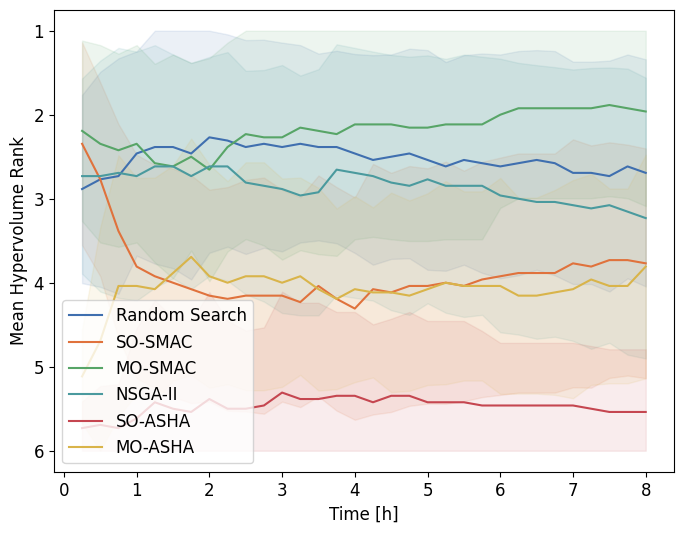

In [38]:
fast = get_group_task_ids("fast")
plot_bmp_hist(fast, metrics_over_time, metric_name="Hypervolume")

Plotting Hypervolume using ranks


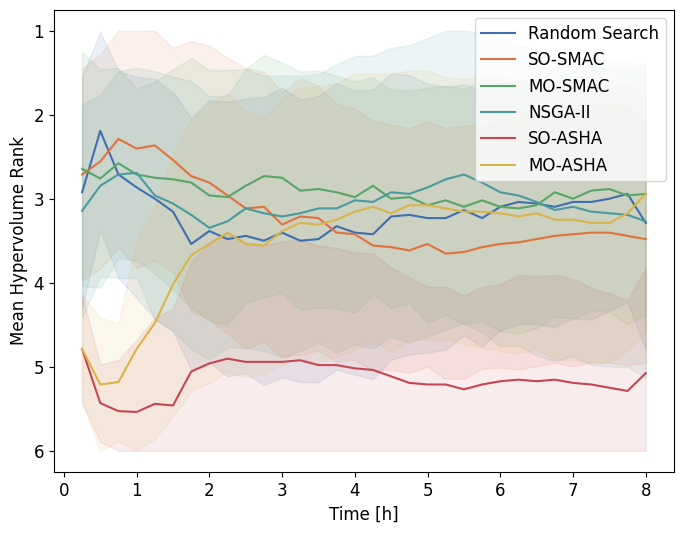

In [39]:
medium = get_group_task_ids("medium")
plot_bmp_hist(medium, metrics_over_time, metric_name="Hypervolume")

Plotting Hypervolume using ranks


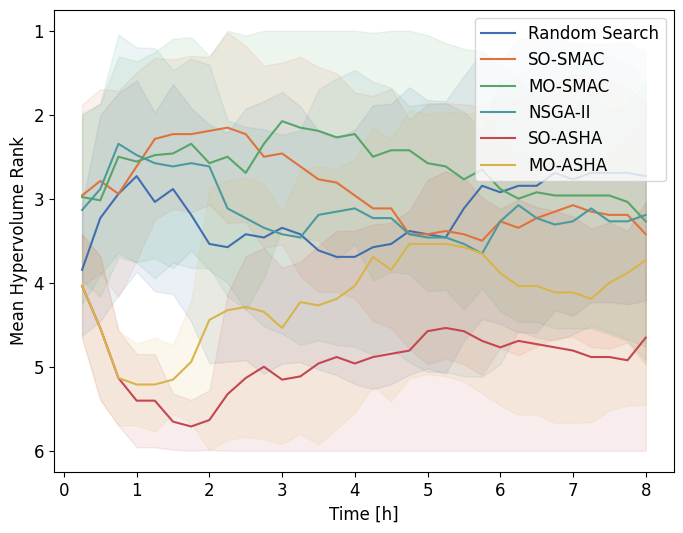

In [40]:
slow = get_group_task_ids("slow")
plot_bmp_hist(slow, metrics_over_time, metric_name="Hypervolume")

In [46]:
def compute_nonsig_groups(mean_ranks, cd):
    """
    mean_ranks: array of shape (M,) with mean ranks for each treatment
    cd: critical distance
    
    Returns a list of groups (each group is a list of indices)
    that are NOT significantly different.
    """
    M = len(mean_ranks)
    
    # Sort indices by mean rank
    sorted_idx = np.argsort(mean_ranks)
    sorted_ranks = mean_ranks[sorted_idx]
    
    groups = []
    i = 0
    while i < M:
        group = [sorted_idx[i]]
        j = i + 1
        while j < M:
            # If difference between ranks <= CD, treatments are NOT significantly different
            if sorted_ranks[j] - sorted_ranks[i] <= cd:
                group.append(sorted_idx[j])
                j += 1
            else:
                break
        groups.append(group)
        i = i+1  # move to next group

    def is_subset(small, big):
        return all(item in big for item in small)

    groups = [g for g in groups if len(g) > 1]
    sorted_groups = sorted(groups, key=lambda x: len(x), reverse=False)

    remove_indices = []
    for i in range(len(sorted_groups)):
        if any(is_subset(sorted_groups[i], sorted_groups[j]) for j in range(len(sorted_groups)) if j != i):
            remove_indices.append(i)

    return [sorted_groups[i] for i in range(len(sorted_groups)) if i not in remove_indices]

def create_cd_2d(mean_ranks, cd, diagram_names, treatment_names, figsize=(9,6), xlabel=None, save_path=None):
    fig, ax = plt.subplots(figsize=figsize)

    # Remove borders and ticks
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.tick_params(length=0)

    # Set ticks and grid
    ax.set_xticks(1 + np.arange(len(treatment_names)))  # x grid every 1 unit
    ax.set_yticks(np.arange(len(diagram_names)))
    ax.grid(True, alpha=0.6)
    ax.invert_xaxis()  # Invert x-axis
    ax.set_xlim(1, len(treatment_names)+.005)

    # Y-axis labels
    ax.set_yticklabels(diagram_names[::-1], ha="right", fontsize=14)
    ax.set_xticklabels(1 + np.arange(len(treatment_names)), fontsize=14)

    if xlabel is not None:
        ax.set_xlabel(xlabel)

    # Scatter plot
    treatment_markers = ["s","o", "*","x","^","2"]
    treatment_colors = COLORS_LIST

    scatter_handles = []

    for i, diagram_name in enumerate(diagram_names):
        ranks = mean_ranks[i]
        cd_val = cd[i]

        groups_nonsig = compute_nonsig_groups(ranks, cd_val)
        for i_group, group in enumerate(groups_nonsig):
            group_ranks = ranks[group]
            x_start = group_ranks.min()
            x_end = group_ranks.max()
            y_pos = len(diagram_names) - 1 - i - 0.2 - i_group * 0.1
            ax.hlines(y=y_pos, xmin=x_start, xmax=x_end, color='black', linewidth=1)
            #ax.vlines(x=x_start, ymin=y_pos, ymax=y_pos + 0.05, color='black', linewidth=1)
            #ax.vlines(x=x_end, ymin=y_pos, ymax=y_pos + 0.05, color='black', linewidth=1)

        for j, treatment_name in enumerate(treatment_names):
            sc = ax.scatter(
                ranks[j], len(diagram_names) - 1 - i, 
                marker=treatment_markers[j % len(treatment_markers)],
                color=treatment_colors[j % len(treatment_colors)], 
                s=100, alpha=1,
            )
            scatter_handles.append(sc)
            groups_with_j_indices = [i for i, g in enumerate(groups_nonsig) if j in g]
            max_index = max(groups_with_j_indices) if groups_with_j_indices else -1
            if max_index >= 0:
                ax.vlines(x=ranks[j], ymin=len(diagram_names) - 1 - i, ymax=len(diagram_names) - 1 - i - 0.2 - (max_index * 0.1), linewidth=1, color="black", linestyles="dotted")        

    # Legend outside to the right
    plt.legend(
        handles=scatter_handles[:len(treatment_names)],  # only scatter points
        labels=treatment_names,
        bbox_to_anchor=(1, 0.5),
        loc='center left',
        fontsize=14
    )
    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path)
    else:
        plt.show()

In [47]:
import autorank
from scipy.stats import rankdata, friedmanchisquare

BMG_METHODS_MAP = {
    "random": "Random Search",
    "so-smac": "SO-SMAC",
    "mo-smac": "MO-SMAC",
    "so-asha": "SO-ASHA",
    "mo-asha": "MO-ASHA",
    "nsga2": "NSGA-II"
}

def significance_test(task_ids, metrics_final, title=None, metric_name="HV", ranks=True, log_scale=False, legend_loc=None, mode="max"):
    metric_index = METRICS.index(metric_name)

    task_id_idx = [task_id_to_idx[t] for t in task_ids]
    metric_final = np.take(metrics_final[task_id_idx], metric_index, axis=-1)
    metric_mean = metric_final.mean(axis=1) # Mean across seeds

    if mode == "min":
        metric_mean = -metric_mean

    stat, p_value = friedmanchisquare(*metric_mean.T)
    print(f"Friedman test for {metric_name}: stat={stat}, p={p_value} => {'significant' if p_value < 0.05 else 'not significant'}")
    metric_df = pd.DataFrame(metric_mean, columns=[BMG_METHODS_MAP[bmg] for bmg in bmg_methods])
    result = autorank.autorank(metric_df, verbose=True, force_mode="nonparametric")
    # Create the CD plot
    fig, ax = plt.subplots(figsize=(9, 2.5))
    plt.rcParams.update({'font.size': 18})
    autorank.plot_stats(result, ax=ax, allow_insignificant=True )
    plt.subplots_adjust(
        left=0.05,    # Left margin (as a fraction of figure width)
        right=0.95,   # Right margin
        bottom=0.0,   # Bottom margin
        top=1.0,      # Top margin
        wspace=0.2,   # Width space between subplots
        hspace=0.2    # Height space between subplots
    )
    if title is not None:
        plt.title(title)
    plt.show()

In [48]:
def multi_cd(metric_list, labels, metric_name="HV", mode="max", figsize=(9,6), save_path=None):
    mean_ranks, cds = [], []
    for metrics_arr in metric_list:
        metric_final = np.take(metrics_arr, METRICS.index(metric_name), axis=-1)
        print(metric_final.shape)
        metric_mean = metric_final.mean(axis=1) # Mean across seeds
        print(metric_mean.shape)

        if mode == "min":
            metric_mean = -metric_mean
        
        metric_df = pd.DataFrame(metric_mean, columns=[BMG_METHODS_MAP[bmg] for bmg in bmg_methods])
        result = autorank.autorank(metric_df, verbose=True, force_mode="nonparametric")
        mean_ranks.append(result.rankdf["meanrank"])
        cds.append(result.cd)

    mean_ranks_array = np.array([[mr_df[BMG_METHODS_MAP[bmg]] for bmg in bmg_methods] for mr_df in mean_ranks])

    create_cd_2d(
        mean_ranks_array,
        cds,
        labels, 
        [BMG_METHODS_MAP[bmg] for bmg in bmg_methods],
        figsize=figsize,
        xlabel=f"Mean {metric_name} Rank",
        save_path=save_path
    )



(104, 5, 6)
(104, 6)
Tests for normality and homoscedacity are ignored for test selection, forcing nonparametric tests
Fail to reject null hypothesis that data is normal for column Random Search (p=0.037854>=0.008333)
Fail to reject null hypothesis that data is normal for column SO-SMAC (p=0.010274>=0.008333)
Fail to reject null hypothesis that data is normal for column MO-SMAC (p=0.169103>=0.008333)
Fail to reject null hypothesis that data is normal for column NSGA-II (p=0.012012>=0.008333)
Rejecting null hypothesis that data is normal for column SO-ASHA (p=0.000000<0.008333)
Rejecting null hypothesis that data is normal for column MO-ASHA (p=0.000000<0.008333)
Using Levene's test for homoscedacity of non-normal data.
Rejecting null hypothesis that all variances are equal (p=0.000308<0.050000)
Using Friedman test as omnibus test
Rejecting null hypothesis that there is no difference between the distributions (p=0.000000)
Using Nemenyi post-hoc test. Differences are significant,if the d

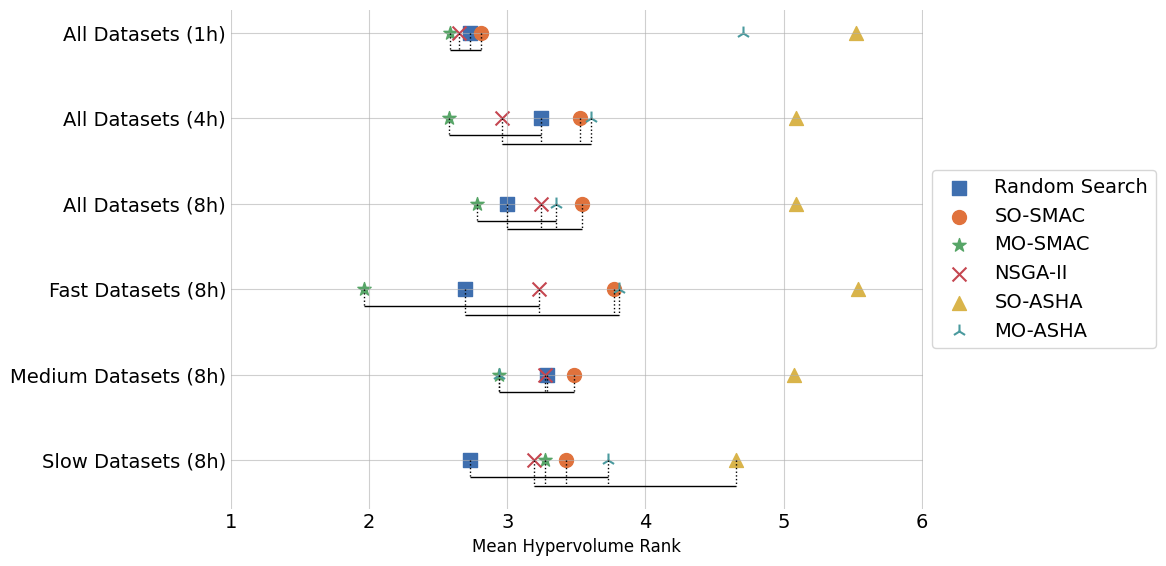

In [50]:
labels = ["All Datasets (1h)", "All Datasets (4h)", "All Datasets (8h)", "Fast Datasets (8h)", "Medium Datasets (8h)", "Slow Datasets (8h)"]

fast_ids = [task_id_to_idx[t] for t in get_group_task_ids("fast")]
medium_ids = [task_id_to_idx[t] for t in get_group_task_ids("medium")]
slow_ids = [task_id_to_idx[t] for t in get_group_task_ids("slow")]

metrics_list = [
    metrics_over_time[:, :, :, time_to_idx[3600.0], :],
    metrics_over_time[:, :, :, time_to_idx[14400.0], :],
    final_metrics,
    final_metrics[fast_ids],
    final_metrics[medium_ids],
    final_metrics[slow_ids],
]


multi_cd(
    metrics_list,
    labels,
    metric_name="Hypervolume", mode="max",
    figsize=(12, 6),
    save_path="./figures/bmg/bmp_hv_cd.pdf"
)

(104, 5, 6)
(104, 6)
Tests for normality and homoscedacity are ignored for test selection, forcing nonparametric tests
Rejecting null hypothesis that data is normal for column Random Search (p=0.000000<0.008333)
Rejecting null hypothesis that data is normal for column SO-SMAC (p=0.000000<0.008333)
Rejecting null hypothesis that data is normal for column MO-SMAC (p=0.000000<0.008333)
Rejecting null hypothesis that data is normal for column NSGA-II (p=0.000000<0.008333)
Rejecting null hypothesis that data is normal for column SO-ASHA (p=0.000000<0.008333)
Rejecting null hypothesis that data is normal for column MO-ASHA (p=0.000000<0.008333)
Using Levene's test for homoscedacity of non-normal data.
Rejecting null hypothesis that all variances are equal (p=0.000000<0.050000)
Using Friedman test as omnibus test
Rejecting null hypothesis that there is no difference between the distributions (p=0.000000)
Using Nemenyi post-hoc test. Differences are significant,if the distance between the mean

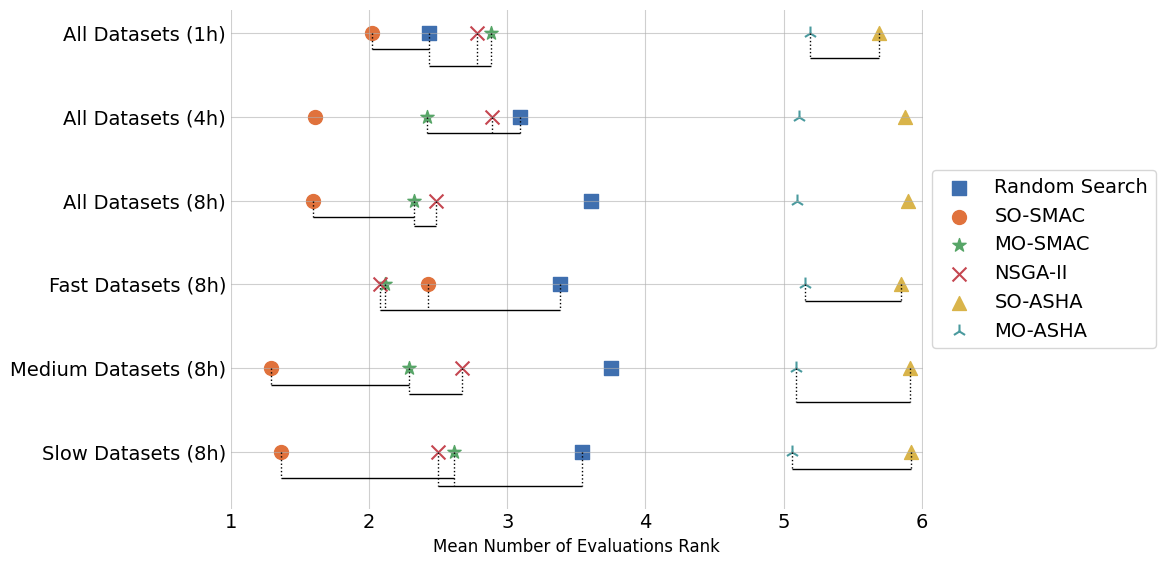

In [52]:
multi_cd(
    metrics_list,
    labels,
    metric_name="Number of Evaluations", mode="max",
    figsize=(12, 6)
)

(104, 5, 6)
(104, 6)
Tests for normality and homoscedacity are ignored for test selection, forcing nonparametric tests
Fail to reject null hypothesis that data is normal for column Random Search (p=0.321951>=0.008333)
Fail to reject null hypothesis that data is normal for column SO-SMAC (p=0.055112>=0.008333)
Fail to reject null hypothesis that data is normal for column MO-SMAC (p=0.074229>=0.008333)
Fail to reject null hypothesis that data is normal for column NSGA-II (p=0.113595>=0.008333)
Fail to reject null hypothesis that data is normal for column SO-ASHA (p=0.839861>=0.008333)
Fail to reject null hypothesis that data is normal for column MO-ASHA (p=0.453811>=0.008333)
Using Bartlett's test for homoscedacity of normally distributed data
Rejecting null hypothesis that all variances are equal (p=0.004821<0.050000)
Using Friedman test as omnibus test
Rejecting null hypothesis that there is no difference between the distributions (p=0.000000)
Using Nemenyi post-hoc test. Differences a

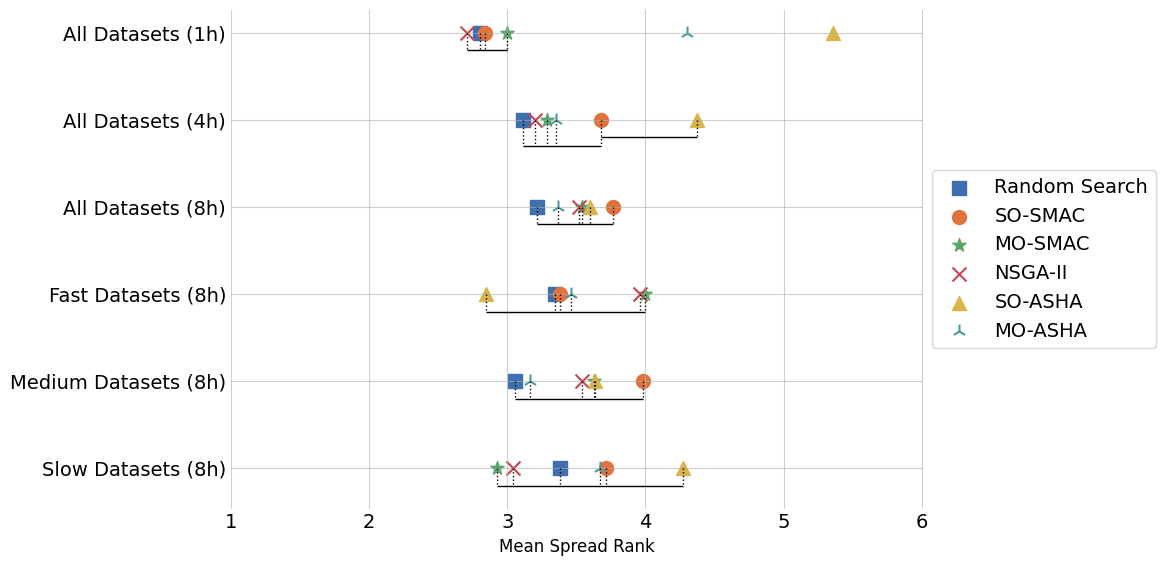

In [53]:
multi_cd(
    metrics_list,
    labels,
    metric_name="Spread", mode="min",
    figsize=(12, 6)
)

(104, 5, 6)
(104, 6)
Tests for normality and homoscedacity are ignored for test selection, forcing nonparametric tests
Fail to reject null hypothesis that data is normal for column Random Search (p=0.580163>=0.008333)
Fail to reject null hypothesis that data is normal for column SO-SMAC (p=0.252117>=0.008333)
Fail to reject null hypothesis that data is normal for column MO-SMAC (p=0.048658>=0.008333)
Fail to reject null hypothesis that data is normal for column NSGA-II (p=0.060991>=0.008333)
Rejecting null hypothesis that data is normal for column SO-ASHA (p=0.000009<0.008333)
Rejecting null hypothesis that data is normal for column MO-ASHA (p=0.001064<0.008333)
Using Levene's test for homoscedacity of non-normal data.
Rejecting null hypothesis that all variances are equal (p=0.000121<0.050000)
Using Friedman test as omnibus test
Rejecting null hypothesis that there is no difference between the distributions (p=0.000000)
Using Nemenyi post-hoc test. Differences are significant,if the d

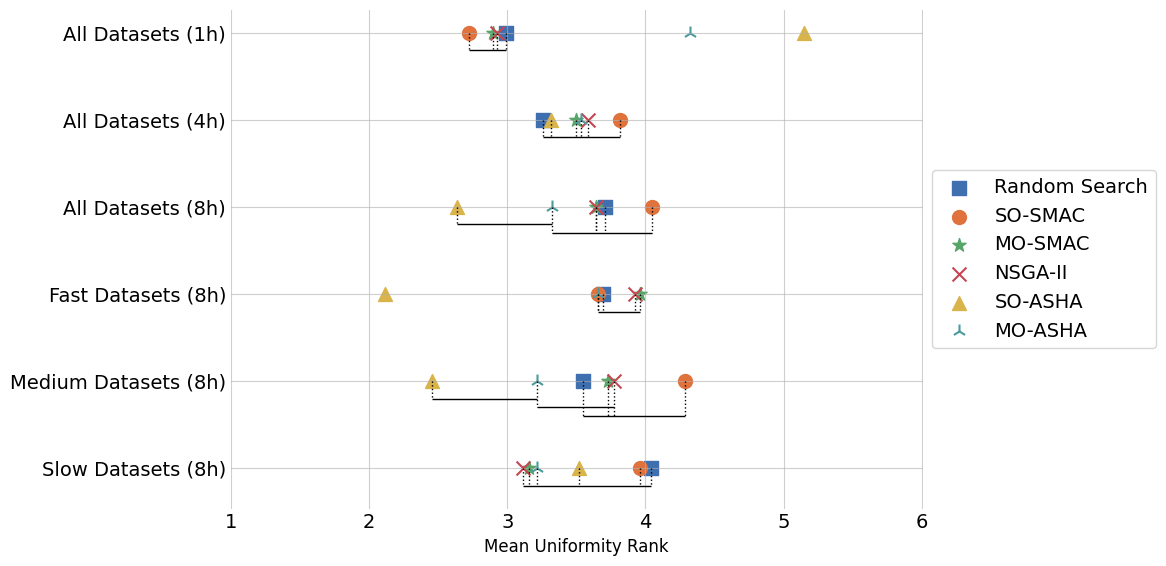

In [54]:
multi_cd(
    metrics_list,
    labels,
    metric_name="Uniformity", mode="min",
    figsize=(12, 6)
)

(104, 5, 6)
(104, 6)
Tests for normality and homoscedacity are ignored for test selection, forcing nonparametric tests
Rejecting null hypothesis that data is normal for column Random Search (p=0.000099<0.008333)
Rejecting null hypothesis that data is normal for column SO-SMAC (p=0.001728<0.008333)
Rejecting null hypothesis that data is normal for column MO-SMAC (p=0.000049<0.008333)
Rejecting null hypothesis that data is normal for column NSGA-II (p=0.000055<0.008333)
Rejecting null hypothesis that data is normal for column SO-ASHA (p=0.006598<0.008333)
Rejecting null hypothesis that data is normal for column MO-ASHA (p=0.003441<0.008333)
Using Levene's test for homoscedacity of non-normal data.
Rejecting null hypothesis that all variances are equal (p=0.000154<0.050000)
Using Friedman test as omnibus test
Rejecting null hypothesis that there is no difference between the distributions (p=0.000000)
Using Nemenyi post-hoc test. Differences are significant,if the distance between the mean

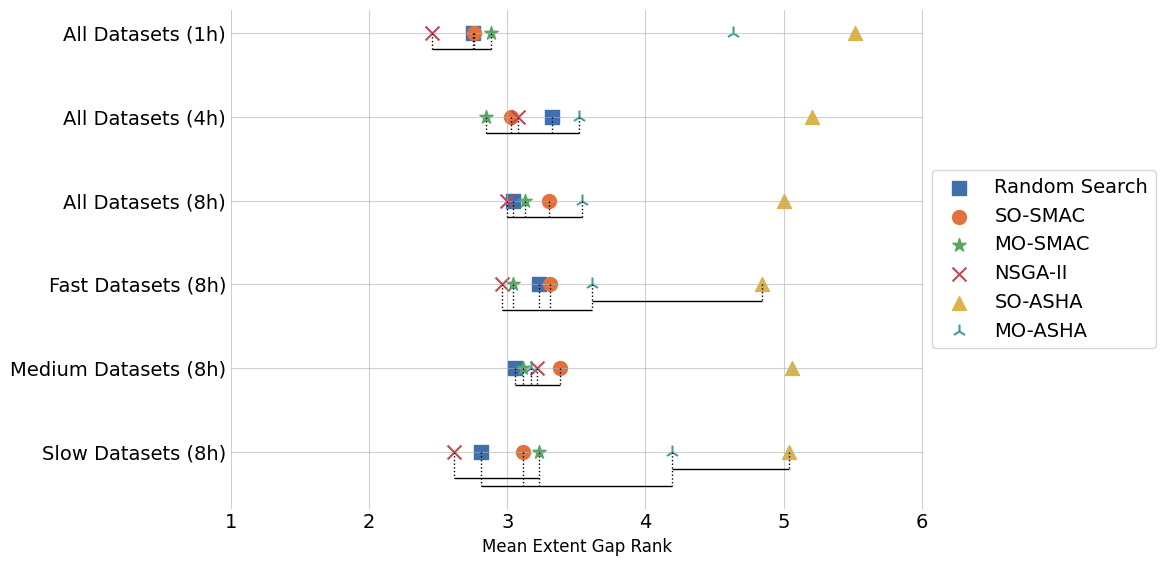

In [55]:
multi_cd(
    metrics_list,
    labels,
    metric_name="Extent Gap", mode="min",
    figsize=(12, 6)
)

Friedman test for Hypervolume: stat=248.79809042403832, p=9.953975899087536e-52 => significant
Tests for normality and homoscedacity are ignored for test selection, forcing nonparametric tests
Fail to reject null hypothesis that data is normal for column Random Search (p=0.037854>=0.008333)
Fail to reject null hypothesis that data is normal for column SO-SMAC (p=0.010274>=0.008333)
Fail to reject null hypothesis that data is normal for column MO-SMAC (p=0.169103>=0.008333)
Fail to reject null hypothesis that data is normal for column NSGA-II (p=0.012012>=0.008333)
Rejecting null hypothesis that data is normal for column SO-ASHA (p=0.000000<0.008333)
Rejecting null hypothesis that data is normal for column MO-ASHA (p=0.000000<0.008333)
Using Levene's test for homoscedacity of non-normal data.
Rejecting null hypothesis that all variances are equal (p=0.000308<0.050000)
Using Friedman test as omnibus test
Rejecting null hypothesis that there is no difference between the distributions (p=0

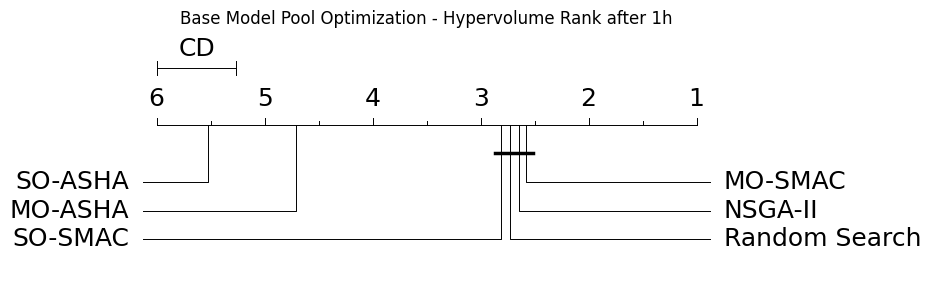

In [56]:
results_1h = metrics_over_time[:, :, :, time_to_idx[3600.0], :]

significance_test(task_ids, results_1h, title="Base Model Pool Optimization - Hypervolume Rank after 1h", metric_name="Hypervolume")

Friedman test for Hypervolume: stat=111.08791208791217, p=2.413015525121251e-22 => significant
Tests for normality and homoscedacity are ignored for test selection, forcing nonparametric tests
Rejecting null hypothesis that data is normal for column Random Search (p=0.001025<0.008333)
Rejecting null hypothesis that data is normal for column SO-SMAC (p=0.000963<0.008333)
Rejecting null hypothesis that data is normal for column MO-SMAC (p=0.001645<0.008333)
Rejecting null hypothesis that data is normal for column NSGA-II (p=0.000204<0.008333)
Rejecting null hypothesis that data is normal for column SO-ASHA (p=0.000021<0.008333)
Rejecting null hypothesis that data is normal for column MO-ASHA (p=0.000002<0.008333)
Using Levene's test for homoscedacity of non-normal data.
Fail to reject null hypothesis that all variances are equal (p=0.116496>=0.050000)
Using Friedman test as omnibus test
Rejecting null hypothesis that there is no difference between the distributions (p=0.000000)
Using Nem

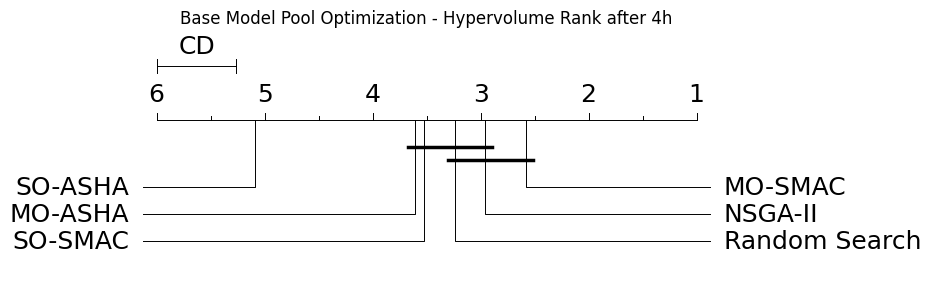

In [57]:
results_4h = metrics_over_time[:, :, :, time_to_idx[14400.0], :]
significance_test(task_ids, results_4h, title="Base Model Pool Optimization - Hypervolume Rank after 4h", metric_name="Hypervolume")

Significance test for group: Fast Datasets
Friedman test for Hypervolume: stat=55.076923076923094, p=1.2586513967478842e-10 => significant
Tests for normality and homoscedacity are ignored for test selection, forcing nonparametric tests
Fail to reject null hypothesis that data is normal for column Random Search (p=0.195029>=0.008333)
Fail to reject null hypothesis that data is normal for column SO-SMAC (p=0.254810>=0.008333)
Fail to reject null hypothesis that data is normal for column MO-SMAC (p=0.070845>=0.008333)
Fail to reject null hypothesis that data is normal for column NSGA-II (p=0.083202>=0.008333)
Fail to reject null hypothesis that data is normal for column SO-ASHA (p=0.129841>=0.008333)
Fail to reject null hypothesis that data is normal for column MO-ASHA (p=0.082449>=0.008333)
Using Bartlett's test for homoscedacity of normally distributed data
Fail to reject null hypothesis that all variances are equal (p=0.999626>=0.050000)
Using Friedman test as omnibus test
Rejecting n

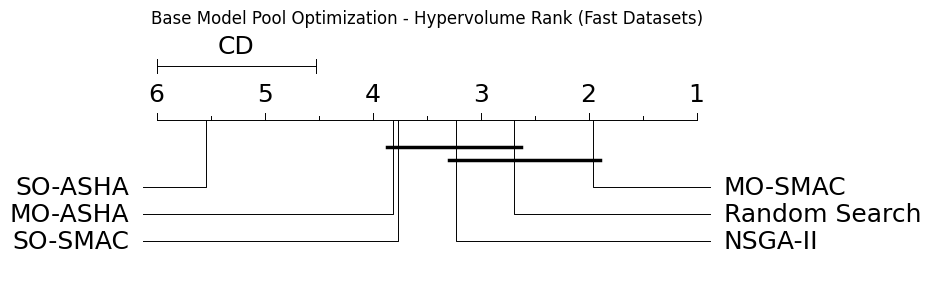

Significance test for group: Medium Datasets
Friedman test for Hypervolume: stat=47.64835164835176, p=4.190142916786882e-09 => significant
Tests for normality and homoscedacity are ignored for test selection, forcing nonparametric tests
Fail to reject null hypothesis that data is normal for column Random Search (p=0.311492>=0.008333)
Fail to reject null hypothesis that data is normal for column SO-SMAC (p=0.373416>=0.008333)
Fail to reject null hypothesis that data is normal for column MO-SMAC (p=0.313916>=0.008333)
Fail to reject null hypothesis that data is normal for column NSGA-II (p=0.295949>=0.008333)
Fail to reject null hypothesis that data is normal for column SO-ASHA (p=0.181792>=0.008333)
Fail to reject null hypothesis that data is normal for column MO-ASHA (p=0.022400>=0.008333)
Using Bartlett's test for homoscedacity of normally distributed data
Fail to reject null hypothesis that all variances are equal (p=0.715289>=0.050000)
Using Friedman test as omnibus test
Rejecting n

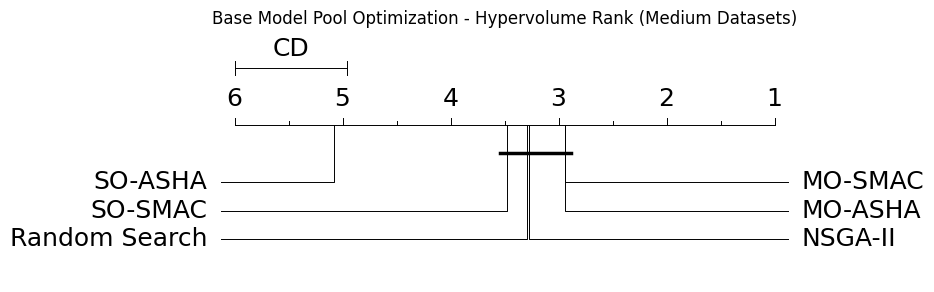

Significance test for group: Slow Datasets
Friedman test for Hypervolume: stat=15.824175824175882, p=0.00736440640496183 => significant
Tests for normality and homoscedacity are ignored for test selection, forcing nonparametric tests
Fail to reject null hypothesis that data is normal for column Random Search (p=0.052682>=0.008333)
Fail to reject null hypothesis that data is normal for column SO-SMAC (p=0.066972>=0.008333)
Fail to reject null hypothesis that data is normal for column MO-SMAC (p=0.060984>=0.008333)
Fail to reject null hypothesis that data is normal for column NSGA-II (p=0.038560>=0.008333)
Fail to reject null hypothesis that data is normal for column SO-ASHA (p=0.032359>=0.008333)
Fail to reject null hypothesis that data is normal for column MO-ASHA (p=0.013279>=0.008333)
Using Bartlett's test for homoscedacity of normally distributed data
Fail to reject null hypothesis that all variances are equal (p=0.966723>=0.050000)
Using Friedman test as omnibus test
Rejecting null

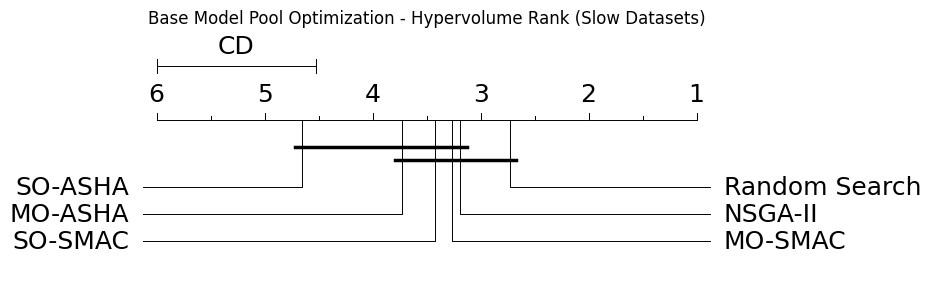

Significance test for group: Binary Classification
Friedman test for Hypervolume: stat=46.24041811846689, p=8.113951541481303e-09 => significant
Tests for normality and homoscedacity are ignored for test selection, forcing nonparametric tests
Rejecting null hypothesis that data is normal for column Random Search (p=0.001937<0.008333)
Rejecting null hypothesis that data is normal for column SO-SMAC (p=0.003215<0.008333)
Rejecting null hypothesis that data is normal for column MO-SMAC (p=0.007859<0.008333)
Rejecting null hypothesis that data is normal for column NSGA-II (p=0.000129<0.008333)
Rejecting null hypothesis that data is normal for column SO-ASHA (p=0.006401<0.008333)
Rejecting null hypothesis that data is normal for column MO-ASHA (p=0.000313<0.008333)
Using Levene's test for homoscedacity of non-normal data.
Fail to reject null hypothesis that all variances are equal (p=0.967957>=0.050000)
Using Friedman test as omnibus test
Rejecting null hypothesis that there is no differenc

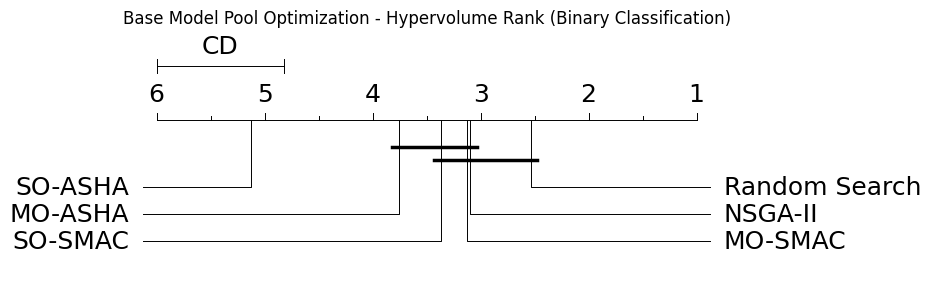

Significance test for group: Multiclass Classification
Friedman test for Hypervolume: stat=28.47619047619048, p=2.9371126347185963e-05 => significant
Tests for normality and homoscedacity are ignored for test selection, forcing nonparametric tests
Fail to reject null hypothesis that data is normal for column Random Search (p=0.180946>=0.008333)
Fail to reject null hypothesis that data is normal for column SO-SMAC (p=0.128757>=0.008333)
Fail to reject null hypothesis that data is normal for column MO-SMAC (p=0.071637>=0.008333)
Fail to reject null hypothesis that data is normal for column NSGA-II (p=0.110546>=0.008333)
Fail to reject null hypothesis that data is normal for column SO-ASHA (p=0.094284>=0.008333)
Fail to reject null hypothesis that data is normal for column MO-ASHA (p=0.169801>=0.008333)
Using Bartlett's test for homoscedacity of normally distributed data
Fail to reject null hypothesis that all variances are equal (p=0.910997>=0.050000)
Using Friedman test as omnibus test


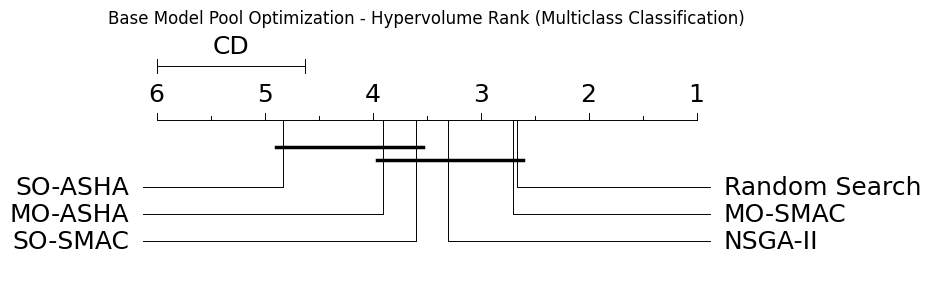

Significance test for group: Regression
Friedman test for Hypervolume: stat=54.610389610389575, p=1.569887593706138e-10 => significant
Tests for normality and homoscedacity are ignored for test selection, forcing nonparametric tests
Fail to reject null hypothesis that data is normal for column Random Search (p=0.133566>=0.008333)
Fail to reject null hypothesis that data is normal for column SO-SMAC (p=0.080566>=0.008333)
Fail to reject null hypothesis that data is normal for column MO-SMAC (p=0.106529>=0.008333)
Fail to reject null hypothesis that data is normal for column NSGA-II (p=0.103757>=0.008333)
Fail to reject null hypothesis that data is normal for column SO-ASHA (p=0.077441>=0.008333)
Fail to reject null hypothesis that data is normal for column MO-ASHA (p=0.071823>=0.008333)
Using Bartlett's test for homoscedacity of normally distributed data
Fail to reject null hypothesis that all variances are equal (p=0.745370>=0.050000)
Using Friedman test as omnibus test
Rejecting null 

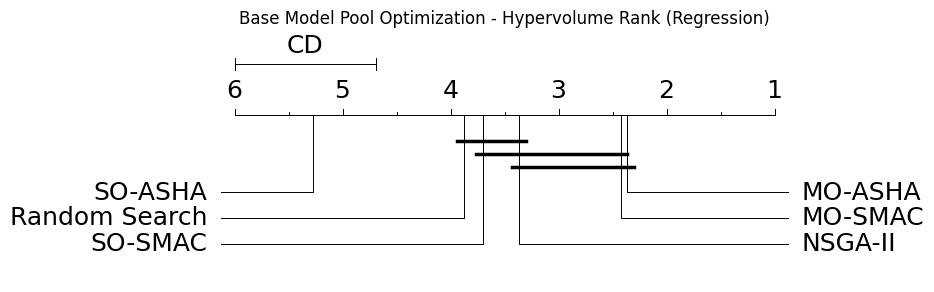

In [58]:
small_ids = get_group_task_ids("fast")
medium_ids = get_group_task_ids("medium")
large_ids = get_group_task_ids("slow")

binary_ids = get_group_task_ids("binary")
multiclass_ids = get_group_task_ids("multiclass")
repression_ids = get_group_task_ids("regression")

groups = {
    "Fast Datasets": small_ids,
    "Medium Datasets": medium_ids,
    "Slow Datasets": large_ids,
    "Binary Classification": binary_ids,
    "Multiclass Classification": multiclass_ids,
    "Regression": repression_ids
}

for group_name in groups.keys():
    print(f"Significance test for group: {group_name}")
    significance_test(groups[group_name], final_metrics, title=f"Base Model Pool Optimization - Hypervolume Rank ({group_name})", metric_name="Hypervolume")